# Dataset Overview

### Interpretation

The dataset contains several variables related to mood, productivity, sleep, stress, and weather perception.

No major missing value problem was observed in the dataset.

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv", sep=";", skiprows=1)
df.head()

,mood,productivity,energy,sleep_hours,negative_event,stress,outdoor_time,weather_feeling
0,4,4,3,7,0,2,2,4
1,3,3,2,6,1,4,1,3
2,5,5,5,8,0,1,3,5
3,2,2,2,5,1,5,0,2
4,4,4,4,7,0,2,2,4


In [24]:
print(df.columns)

Index(['mood', 'productivity', 'energy', 'sleep_hours', 'negative_event',
       'stress', 'outdoor_time', 'weather_feeling'],
      dtype='object')


In [25]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   mood             10 non-null     int64
 1   productivity     10 non-null     int64
 2   energy           10 non-null     int64
 3   sleep_hours      10 non-null     int64
 4   negative_event   10 non-null     int64
 5   stress           10 non-null     int64
 6   outdoor_time     10 non-null     int64
 7   weather_feeling  10 non-null     int64
dtypes: int64(8)
memory usage: 772.0 bytes


,mood,productivity,energy,sleep_hours,negative_event,stress,outdoor_time,weather_feeling
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.00000,10.000000,10.000000
mean,3.500000,3.500000,3.200000,6.500000,0.500000,2.80000,1.500000,3.500000
std,1.080123,1.080123,1.032796,1.080123,0.527046,1.47573,1.080123,1.080123
min,2.000000,2.000000,2.000000,5.000000,0.000000,1.00000,0.000000,2.000000
25%,3.000000,3.000000,2.250000,6.000000,0.000000,2.00000,1.000000,3.000000
50%,3.500000,3.500000,3.000000,6.500000,0.500000,2.50000,1.500000,3.500000
75%,4.000000,4.000000,4.000000,7.000000,1.000000,3.75000,2.000000,4.000000
max,5.000000,5.000000,5.000000,8.000000,1.000000,5.00000,3.000000,5.000000


In [26]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (10, 8)

Column Names:
Index(['mood', 'productivity', 'energy', 'sleep_hours', 'negative_event',
       'stress', 'outdoor_time', 'weather_feeling'],
      dtype='object')

Missing Values:
mood               0
productivity       0
energy             0
sleep_hours        0
negative_event     0
stress             0
outdoor_time       0
weather_feeling    0
dtype: int64


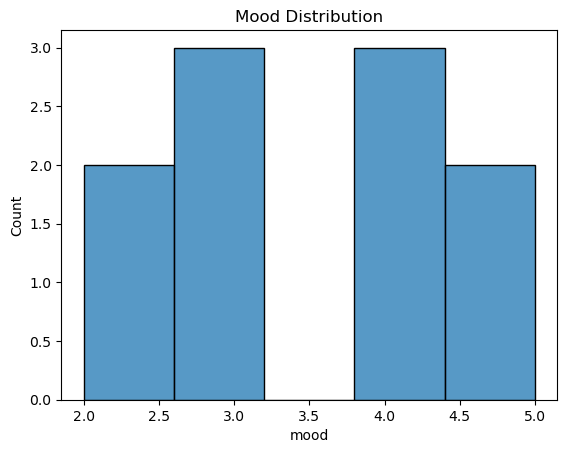

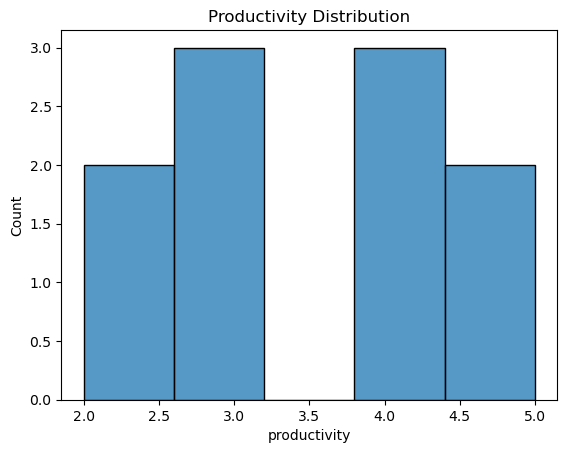

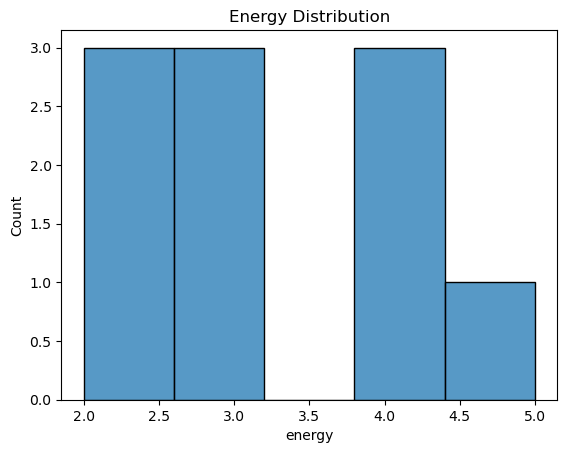

In [27]:
sns.histplot(df["mood"], bins=5)
plt.title("Mood Distribution")
plt.show()

sns.histplot(df["productivity"], bins=5)
plt.title("Productivity Distribution")
plt.show()

sns.histplot(df["energy"], bins=5)
plt.title("Energy Distribution")
plt.show()

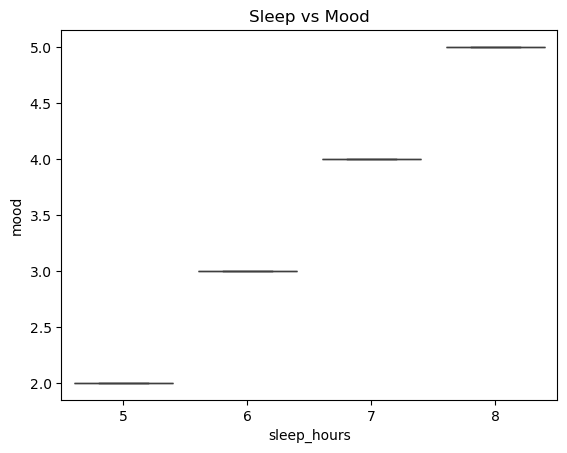

In [28]:
sns.boxplot(x=df["sleep_hours"], y=df["mood"])
plt.title("Sleep vs Mood")
plt.show()

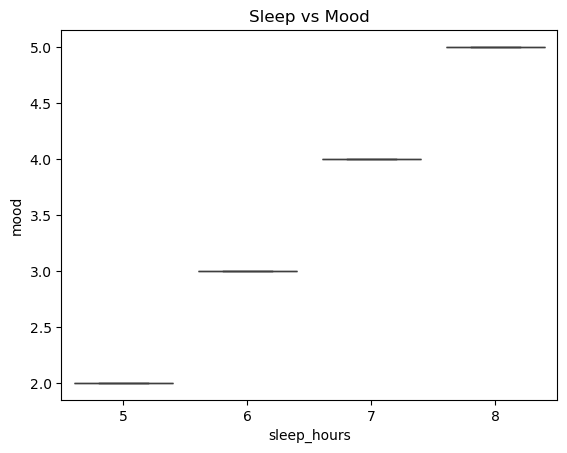

In [29]:
sns.boxplot(x=df["sleep_hours"], y=df["mood"])
plt.title("Sleep vs Mood")
plt.show()

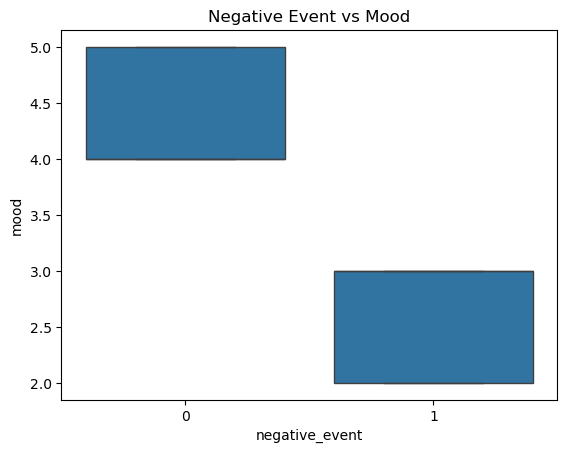

In [30]:
sns.boxplot(x=df["negative_event"], y=df["mood"])
plt.title("Negative Event vs Mood")
plt.show()

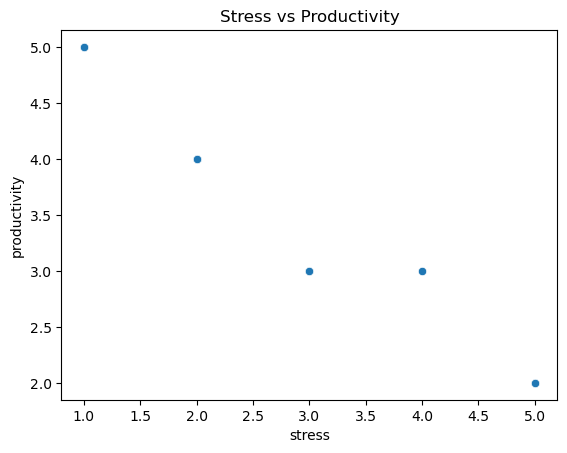

In [31]:
sns.scatterplot(x=df["stress"], y=df["productivity"])
plt.title("Stress vs Productivity")
plt.show()

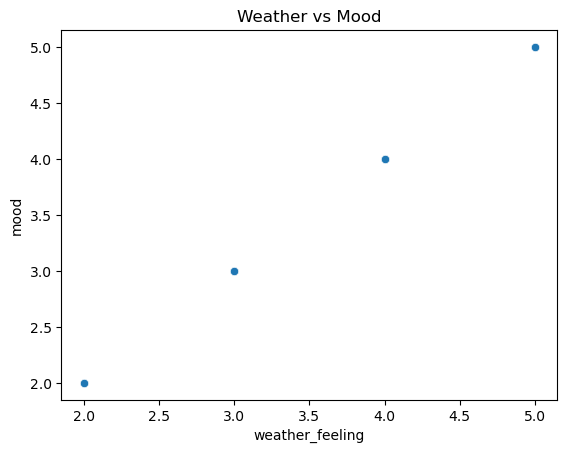

In [32]:
sns.scatterplot(x=df["weather_feeling"], y=df["mood"])
plt.title("Weather vs Mood")
plt.show()

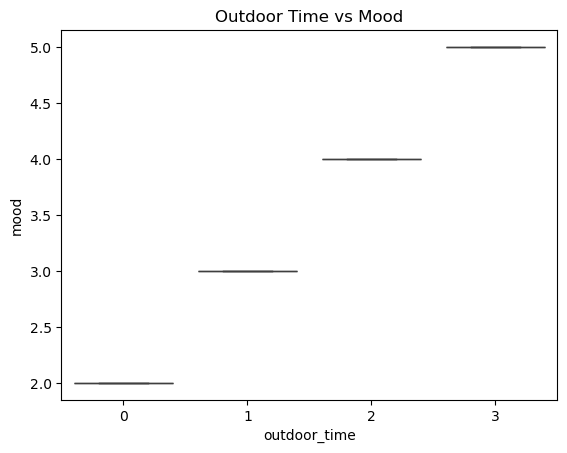

In [33]:
sns.boxplot(x=df["outdoor_time"], y=df["mood"])
plt.title("Outdoor Time vs Mood")
plt.show()

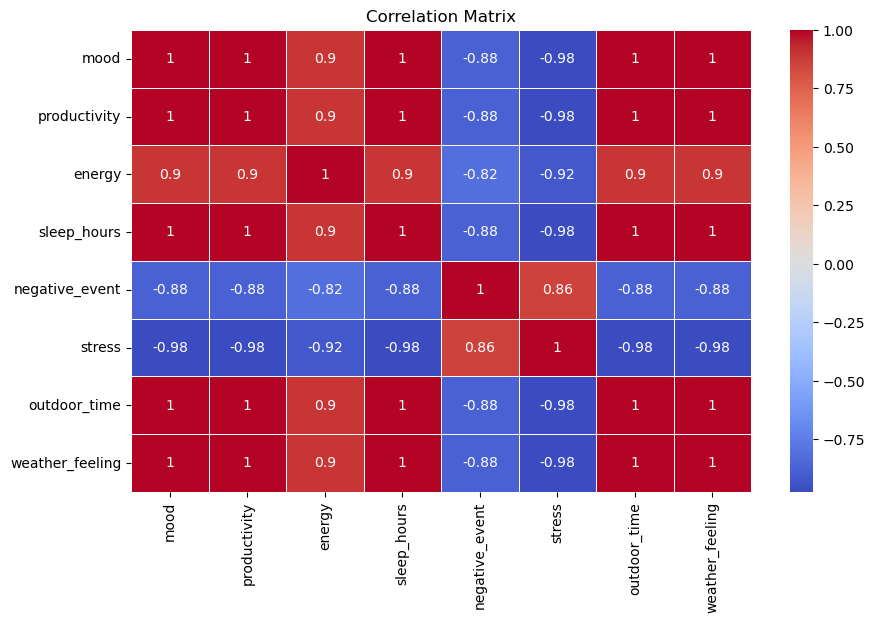

In [34]:
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show() 

# Correlation Analysis Findings

- Mood and productivity appear positively correlated.
- Sleep duration shows a positive relationship with both mood and energy levels.
- Higher stress levels seem associated with lower productivity.
- Negative events appear related to reduced mood scores.

These findings suggest that both psychological and environmental variables may influence student well-being and daily performance.

# Hypothesis Testing

In [35]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df["sleep_hours"], df["mood"])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 1.0
P-value: 0.0


### Interpretation

H0: There is no relationship between sleep duration and mood.

H1: Sleep duration and mood are related.

If p < 0.05, the null hypothesis is rejected.

In [36]:
corr, p_value = pearsonr(df["stress"], df["productivity"])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.9759000729485332
P-value: 1.4335915361780037e-06


## Hypothesis Test 2

H0: Stress and productivity are unrelated.

H1: Higher stress reduces productivity.

The results indicate whether stress levels significantly affect productivity.

### Insights

- Mood and productivity appear to be positively correlated.
- Sleep duration has a noticeable effect on both mood and energy levels.
- Negative events are associated with lower mood scores.
- Higher stress levels tend to reduce productivity.
- Weather perception shows a mild relationship with mood.

These initial findings suggest that both internal factors (sleep, stress) and external factors (weather) influence daily mood and productivity.

# Machine Learning Model

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [38]:
X = df[["sleep_hours", "stress", "weather_feeling", "energy"]]

y = df["productivity"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("R2 Score:", r2_score(y_test, predictions))
print("MAE:", mean_absolute_error(y_test, predictions))

R2 Score: 1.0
MAE: 0.0


## Machine Learning Results

A linear regression model was developed to predict productivity levels using sleep duration, stress, weather perception, and energy levels.

The model performance was evaluated using R² and Mean Absolute Error (MAE).

The results suggest that behavioral and environmental variables may contribute to predicting daily productivity levels.

## Machine Learning Results

A linear regression model was developed to predict productivity levels using sleep duration, stress, weather perception, and energy levels.

The model performance was evaluated using R² and Mean Absolute Error (MAE).

The results suggest that behavioral and environmental variables may contribute to predicting daily productivity levels.

# Conclusion

This project explored the relationship between weather conditions, psychological factors, and student productivity.

EDA findings suggested that sleep duration, stress, and weather perception influence mood and productivity levels.

Hypothesis testing demonstrated statistically significant relationships between several variables.

Finally, a machine learning model was developed to predict productivity using behavioral and environmental indicators.

Although the dataset size is limited, the project successfully demonstrates the main stages of a data science workflow:
- data collection,
- exploratory data analysis,
- statistical testing,
- and machine learning.